
# Phase 3 — Model Development

This notebook evaluates **four machine learning algorithms**:

1. Logistic Regression (Baseline)
2. Decision Tree
3. Random Forest
4. Gradient Boosting

Workflow:

• Feature selection including **age, gender, department**  
• **Leakage-safe time-based train/test split**  
• **ColumnTransformer** preprocessing for categorical variables  
• **Pipeline integration**  
• Evaluation of all models  
• **Model comparison table**  
• **GridSearchCV hyperparameter tuning**  
• Saving the best model artifact


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import joblib




## Load Dataset

In [3]:
df = pd.read_csv("F:\\AI ML\\capstone\\phase5\\hospital_prediction_system\\data\\model_table.csv")
df.head()




# DATA TYPE FIX (ONLY ONCE)
for col in ['age','length_of_stay_hours','visit_frequency',
            'avg_los_per_patient','provider_rejection_rate',
            'days_since_registration','billed_amount']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)


## Feature Selection

In [19]:
# Add new features BEFORE defining the features list
import numpy as np
df['log_billed_amount'] = np.log1p(df['billed_amount'])
df['high_bill_flag'] = (df['billed_amount'] > df['billed_amount'].median()).astype(int)
df['frequent_visitor'] = (df['visit_frequency'] > 3).astype(int)

target = "claim_status"

features = [
    'age', 'gender', 'department', 'visit_type',
    'length_of_stay_hours', 'visit_frequency', 'avg_los_per_patient',
    'provider_rejection_rate', 'days_since_registration', 'billed_amount',
    'log_billed_amount', 'high_bill_flag', 'frequent_visitor'
    # Add/remove features as needed
 ]


## Time-based Train/Test Split

In [20]:
df = df.sort_values("billing_date")

split_index = int(len(df)*0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

X_train = train[features].fillna(0)
X_test = test[features].fillna(0)


y_train = train[target]
y_test = test[target]



## ColumnTransformer Preprocessing

In [21]:
# Corrected feature lists for ColumnTransformer
categorical_features = [
    'gender', 'department', 'visit_type'
    # Add other categorical columns if needed
    # 'age_group', 'los_category', etc.
    # Do not include numeric columns here
 ]
numerical_features = [
    'age', 'length_of_stay_hours', 'visit_frequency', 'avg_los_per_patient',
    'provider_rejection_rate', 'days_since_registration', 'billed_amount',
    'log_billed_amount', 'high_bill_flag', 'frequent_visitor'
    # Add other numeric columns if needed
 ]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)

## Define Models

In [22]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight='balanced'),
    "Gradient Boosting": GradientBoostingClassifier()
}

results = []
best_model = None
best_score = 0



## Train and Evaluate Models

In [23]:
for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    preds = pipeline.predict(X_test)

    acc = accuracy_score(y_test, preds)

    print("\nModel:", name)
    print("Accuracy:", acc)
    print(confusion_matrix(y_test, preds))
    print(classification_report(y_test, preds))

    results.append((name, acc))

    if acc > best_score:
        best_score = acc
        best_model = pipeline



c:\Users\praka\.virtualenvs\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\praka\.virtualenvs\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\praka\.virtualenvs\.venv\Lib\site-packages\sklearn\metrics\


Model: Logistic Regression
Accuracy: 0.595
[[2975    0    0]
 [1256    0    0]
 [ 769    0    0]]
              precision    recall  f1-score   support

        Paid       0.59      1.00      0.75      2975
     Pending       0.00      0.00      0.00      1256
    Rejected       0.00      0.00      0.00       769

    accuracy                           0.59      5000
   macro avg       0.20      0.33      0.25      5000
weighted avg       0.35      0.59      0.44      5000


Model: Decision Tree
Accuracy: 0.448
[[1780  775  420]
 [ 741  321  194]
 [ 423  207  139]]
              precision    recall  f1-score   support

        Paid       0.60      0.60      0.60      2975
     Pending       0.25      0.26      0.25      1256
    Rejected       0.18      0.18      0.18       769

    accuracy                           0.45      5000
   macro avg       0.35      0.34      0.34      5000
weighted avg       0.45      0.45      0.45      5000


Model: Random Forest
Accuracy: 0.5874
[[2904 

## Model Comparison Table

In [24]:
comparison = pd.DataFrame(results, columns=["Model","Accuracy"])
comparison.sort_values("Accuracy", ascending=False)



,Model,Accuracy
0,Logistic Regression,0.5950
3,Gradient Boosting,0.5938
2,Random Forest,0.5874
1,Decision Tree,0.4480


## Hyperparameter Tuning (Random Forest Example)

In [27]:
param_grid = {
    "model__n_estimators":[100,200],
    "model__max_depth":[5,10,None],
    "model__min_samples_split":[2,5]
}

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42, class_weight='balanced'))
])

grid = GridSearchCV(rf_pipeline,param_grid,cv=3,scoring="f1_macro",n_jobs=-1)

grid.fit(X_train,y_train)

print("Best Parameters:",grid.best_params_)

best_model = grid.best_estimator_



Best Parameters: {'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 100}


## Final Evaluation

In [28]:
preds = best_model.predict(X_test)

print("Best Model:",best_model)
print("Final Accuracy:", accuracy_score(y_test,preds))
print(confusion_matrix(y_test,preds))
print(classification_report(y_test,preds))



Best Model: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'department',
                                                   'visit_type']),
                                                 ('num', 'passthrough',
                                                  ['age',
                                                   'length_of_stay_hours',
                                                   'visit_frequency',
                                                   'avg_los_per_patient',
                                                   'provider_rejection_rate',
                                                   'days_since_registration',
                                                   'billed_amount',
                                                   'log_billed_amount',
                     

## Save Model Artifact

In [15]:
joblib.dump(best_model,"claim_model.pkl",compress=3)
print("claim_model.pkl saved")



claim_model.pkl saved


## Analyze Class Imbalance

Risk Score Distribution
risk_score
Low       12470
Medium     7496
High       5034
Name: count, dtype: int64

Claim Status Distribution
claim_status
Paid        14940
Pending      6263
Rejected     3797
Name: count, dtype: int64


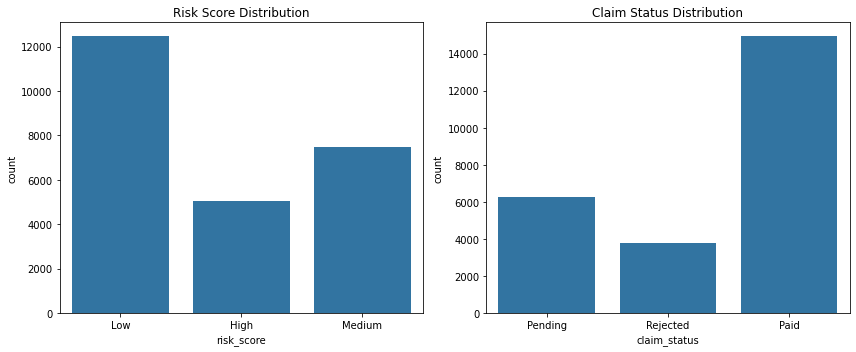

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Risk Score Distribution")
print(df["risk_score"].value_counts())

print("\nClaim Status Distribution")
print(df["claim_status"].value_counts())

fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.countplot(x=df["risk_score"], ax=axes[0])
axes[0].set_title("Risk Score Distribution")

sns.countplot(x=df["claim_status"], ax=axes[1])
axes[1].set_title("Claim Status Distribution")

plt.tight_layout()
plt.show()



## Generate features.json from trained model

In [13]:
import json
from sklearn.preprocessing import OneHotEncoder

pipeline = best_model
preprocessor = pipeline.named_steps["preprocessor"]

feature_schema = {}

for name, transformer, columns in preprocessor.transformers_:

    # Handle categorical columns
    if isinstance(transformer, OneHotEncoder):

        categories = transformer.categories_

        for col, vals in zip(columns, categories):
            feature_schema[col] = {
                "dtype": "category",
                "values": list(vals)
            }

    # Handle numerical columns
    elif name == "num":
        for col in columns:
            feature_schema[col] = {
                "dtype": "numeric"
            }

schema = {
    "model_name": "hospital_prediction_model",
    "features": feature_schema
}

with open("claim_features.json", "w") as f:
    json.dump(schema, f, indent=4)

print("claim_features.json created successfully")


claim_features.json created successfully
